# Task 1: Iris Flower Classification

**Goal:** Train a machine learning model to classify Iris flowers (Setosa, Versicolor, Virginica) based on sepal and petal measurements.

**Steps:**
1. Import libraries
2. Load & explore data
3. Visualize data
4. Prepare data (train/test split)
5. Train model
6. Evaluate model
7. Conclusion


## Step 1: Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline
sns.set(style="whitegrid")

## Step 2: Load & Explore the Data

In [5]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
print("Shape:", df.shape)
df.info()

Shape: (150, 6)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [8]:
# Check for missing values
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [9]:
# Check class distribution
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [10]:
# Drop the Id column - not useful for prediction
df = df.drop('Id', axis=1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Step 3: Visualize the Data

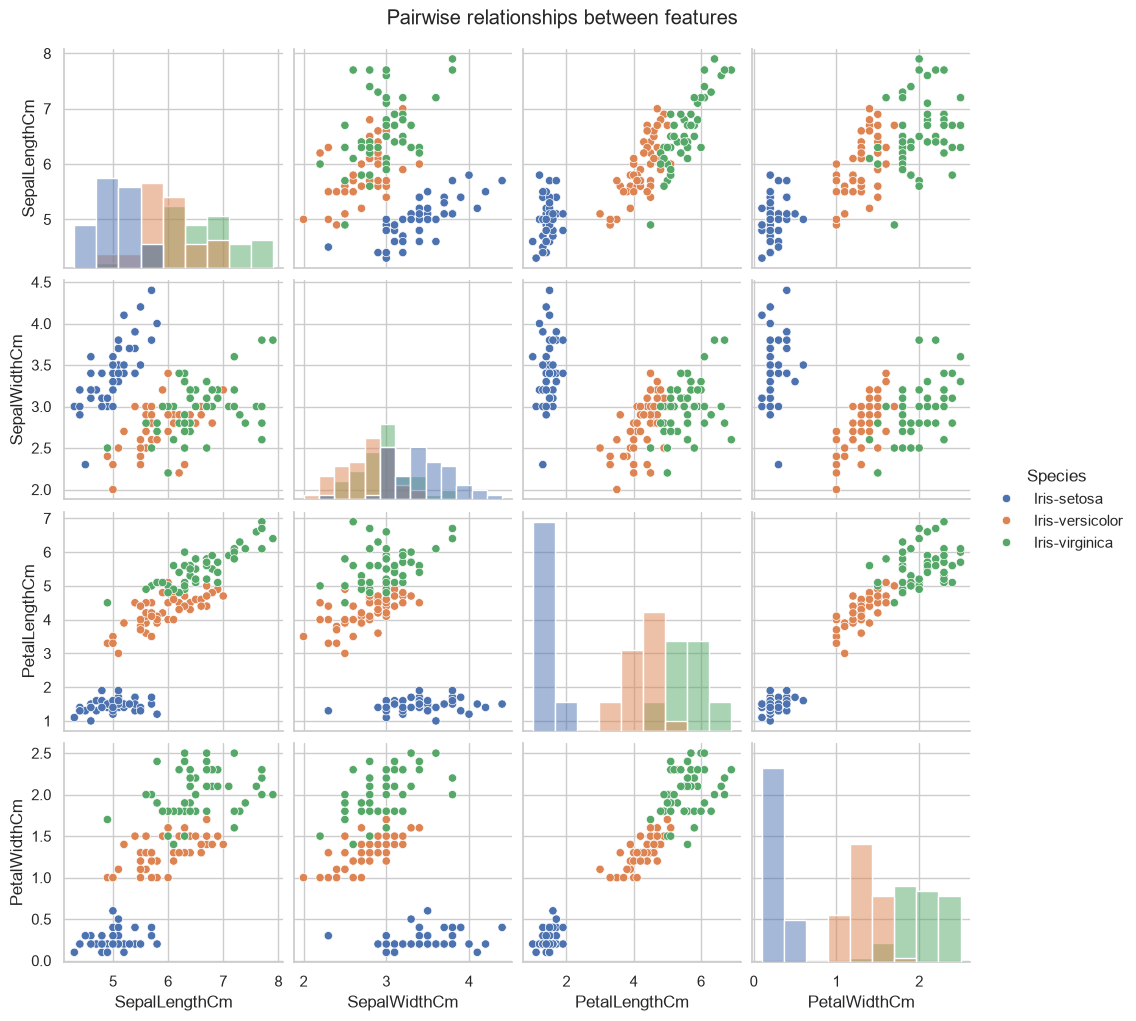

In [11]:
sns.pairplot(df, hue='Species', diag_kind='hist')
plt.suptitle("Pairwise relationships between features", y=1.02)
plt.show()

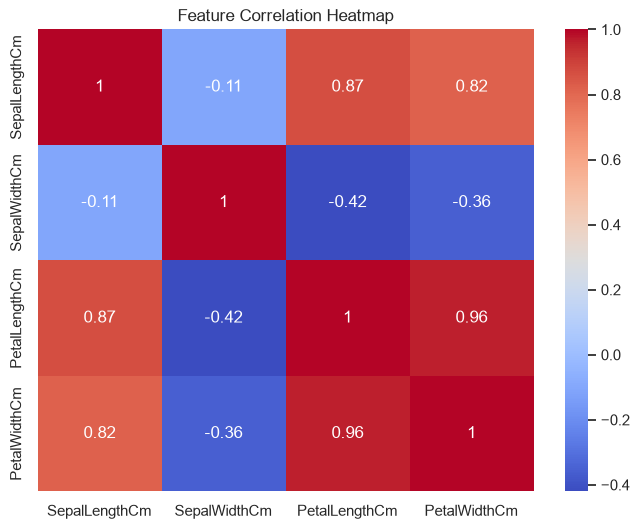

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('Species', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

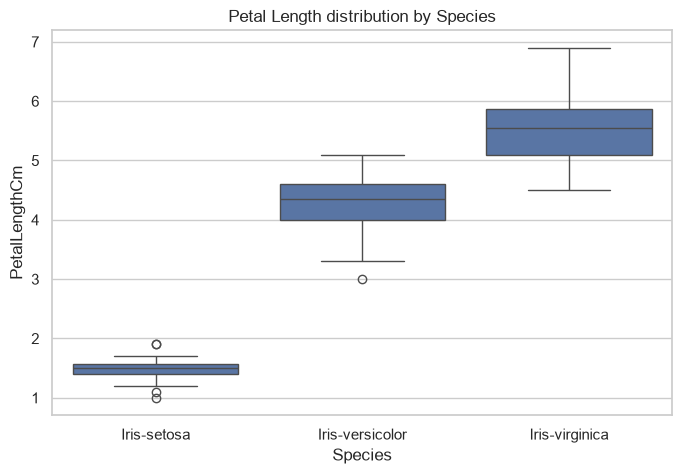

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Species', y='PetalLengthCm', data=df)
plt.title("Petal Length distribution by Species")
plt.show()

**Observation:** Petal length and petal width separate the three species very clearly, more than sepal measurements. This is a strong hint that a simple model will perform very well.

## Step 4: Prepare the Data

In [14]:
X = df.drop('Species', axis=1)
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (120, 4)
Test size: (30, 4)


## Step 5: Train Models

We'll try a few different classifiers and compare them.

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel='linear'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

Logistic Regression: Accuracy = 0.9667
K-Nearest Neighbors: Accuracy = 1.0000
Support Vector Machine: Accuracy = 1.0000
Random Forest: Accuracy = 0.9000


## Step 6: Evaluate the Best Model

In [16]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print("Best model:", best_model_name)

y_pred = best_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best model: K-Nearest Neighbors

Accuracy: 1.0

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



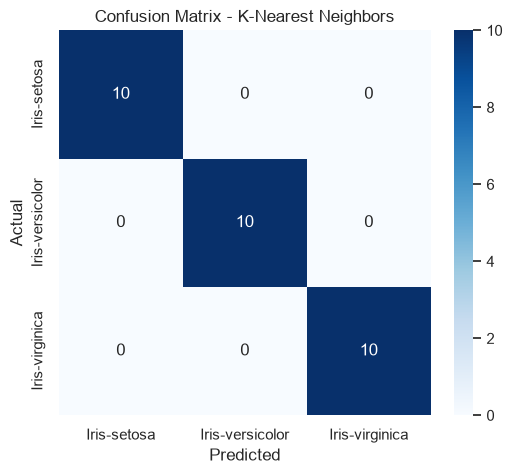

In [17]:
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [18]:
# Feature importance (only meaningful for tree-based models like Random Forest)
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(6,4))
    importances.plot(kind='bar', color='teal')
    plt.title("Feature Importance")
    plt.ylabel("Importance")
    plt.show()
    print(importances)

## Step 7: Conclusion

- All models perform very well on this dataset because the three Iris species are quite well separated by petal measurements.
- The best performing model was selected automatically above based on test accuracy.
- **Petal Length** and **Petal Width** are the most important features for classification, more so than sepal measurements.
- This confirms that even simple, interpretable models can achieve high accuracy (~95-100%) on this classic dataset.

**Next steps (optional improvements):**
- Try cross-validation instead of a single train/test split for a more robust accuracy estimate.
- Try hyperparameter tuning (GridSearchCV) to further improve performance.
- Save the trained model using `joblib` for later use.
